In [21]:
import osmnx as ox
import matplotlib.pyplot as plt
import seaborn as sns
import h3
import pandas as pd
import os
import geopandas as gpd

In [22]:
# Define project parameters
place_name = "Chicago, Illinois, USA"
tags = {'amenity': True, 'shop': True, 'tourism': True}
data_dir = "data"
file_path = os.path.join(data_dir, "chicago_pois.gpkg")

In [23]:
os.makedirs(data_dir, exist_ok=True)

# Check if data is already downloaded
if os.path.exists(file_path):
    print(f"Loading data from local file: {file_path}")
    pois = gpd.read_file(file_path)
else:
    print(f"Data not found. Downloading {place_name} POIs... (This may take a minute)")
    # Download the data
    pois = ox.features_from_place(place_name, tags)
    
    # Save it locally for next time
    # We save as GeoPackage (.gpkg) because it's faster and better for spatial data than CSV
    pois.to_file(file_path, driver="GPKG")
    print(f"Data saved to {file_path}")

print(f"Total POIs loaded: {len(pois)}")
pois.head()

Loading data from local file: data/chicago_pois.gpkg
Total POIs loaded: 43237


,element,id,amenity,ferry,name,network,operator,public_transport,source,tourism,...,name:tl,not:name,diet:dairy_free,building:levels:underground,building:roof,roof,nohousenumber,levels,abbr_name,geometry
0,node,20217109,ferry_terminal,yes,Shoreline Sightseeing,Shoreline Water Taxi,Shoreline Water Taxi,station,PGS,attraction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.62252 41.88914)
1,node,20217442,ferry_terminal,yes,Union Station/Willis Tower,Shoreline Water Taxi,Shoreline Water Taxi,station,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.63774 41.87906)
2,node,269449042,parking_entrance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.61506 41.85869)
3,node,269450074,parking_entrance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.5842 41.79178)
4,node,269450344,parking_entrance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.61195 41.84968)


In [24]:
# Connect to H3 Hexagons (Task 1 & 2 requirement) [cite: 48, 51]
# We'll use resolution 8 as a starting point for "discretizing the city"
def get_h3_index(row):
    # Ensure we are using the centroid for the index
    # Some OSM features are Polygons; centroid gives us a point
    centroid = row.geometry.centroid
    return h3.latlng_to_cell(centroid.y, centroid.x, 8)

pois['h3_index'] = pois.apply(get_h3_index, axis=1)

In [25]:
unique_amenities = pois['amenity'].dropna().unique()

print(f"Total unique amenities: {len(unique_amenities)}")
print(unique_amenities)

# Display the first few rows
pois[['amenity', 'shop', 'tourism', 'h3_index']].head()

Total unique amenities: 138
<StringArray>
[    'ferry_terminal',   'parking_entrance',           'post_box',
       'loading_dock',            'theatre',    'bicycle_parking',
          'fast_food',        'post_office',     'drinking_water',
         'restaurant',
 ...
 'vehicle_inspection',       'nursing_home',           'mortuary',
          'monastery',         'fraternity',       'boat_storage',
        'trolley_bay',     'security_booth',    'animal_training',
    'outdoor_seating']
Length: 138, dtype: str


,amenity,shop,tourism,h3_index
0,ferry_terminal,NaN,attraction,882664c1e3fffff
1,ferry_terminal,NaN,NaN,882664c1adfffff
2,parking_entrance,NaN,NaN,882664c1b1fffff
3,parking_entrance,NaN,NaN,882664cc59fffff
4,parking_entrance,NaN,NaN,882664c1b3fffff


In [26]:
missing_amenity_df = pois[pois['amenity'].isna()]
print(f"Total rows with missing amenity: {len(missing_amenity_df)}")
cols_to_show = ['id', 'name', 'shop', 'tourism', 'geometry', 'h3_index']
existing_cols = [c for c in cols_to_show if c in pois.columns]
missing_amenity_df[existing_cols].head(20)

Total rows with missing amenity: 7053


,id,name,shop,tourism,geometry,h3_index
6,269691663,Edgebrook Cycle,bicycle,NaN,POINT (-87.7634 41.99887),882664d9e3fffff
10,282370094,7-Eleven,convenience,NaN,POINT (-87.8373 41.97632),88275936b1fffff
13,287160477,DePaul University Bookstore,books,NaN,POINT (-87.65341 41.92602),882664c12bfffff
20,306744421,Staples,stationery,NaN,POINT (-87.62591 41.88341),882664c1a9fffff
24,310690970,Barnes & Noble,books,NaN,POINT (-87.62724 41.87802),882664c1a9fffff
44,348168844,Broadway Bikes,bicycle,NaN,POINT (-87.65813 41.96686),882664d895fffff
45,349255925,NaN,vacant,NaN,POINT (-87.67767 41.91036),882664cac1fffff
399,354234605,George Washington Memorial,NaN,artwork,POINT (-87.61643 41.80248),882664cc45fffff
516,354239297,Independence Square Fountain,NaN,artwork,POINT (-87.71947 41.86271),882664c8c1fffff
658,354258876,Vincent de Paul with two students,NaN,artwork,POINT (-87.65547 41.92466),882664c12bfffff


In [27]:
pois["poi_type"] = pois["amenity"]
pois["poi_type"] = pois["poi_type"].fillna(pois["shop"]).fillna(pois["tourism"])

In [28]:
missing_poi_df = pois[pois['poi_type'].isna()]
print(f"Total rows with missing poi_type: {len(missing_poi_df)}")
cols_to_show = ['id', 'name', 'shop', 'tourism', 'geometry', 'h3_index']
existing_cols = [c for c in cols_to_show if c in pois.columns]
missing_poi_df[existing_cols].head(20)

Total rows with missing poi_type: 0


,id,name,shop,tourism,geometry,h3_index


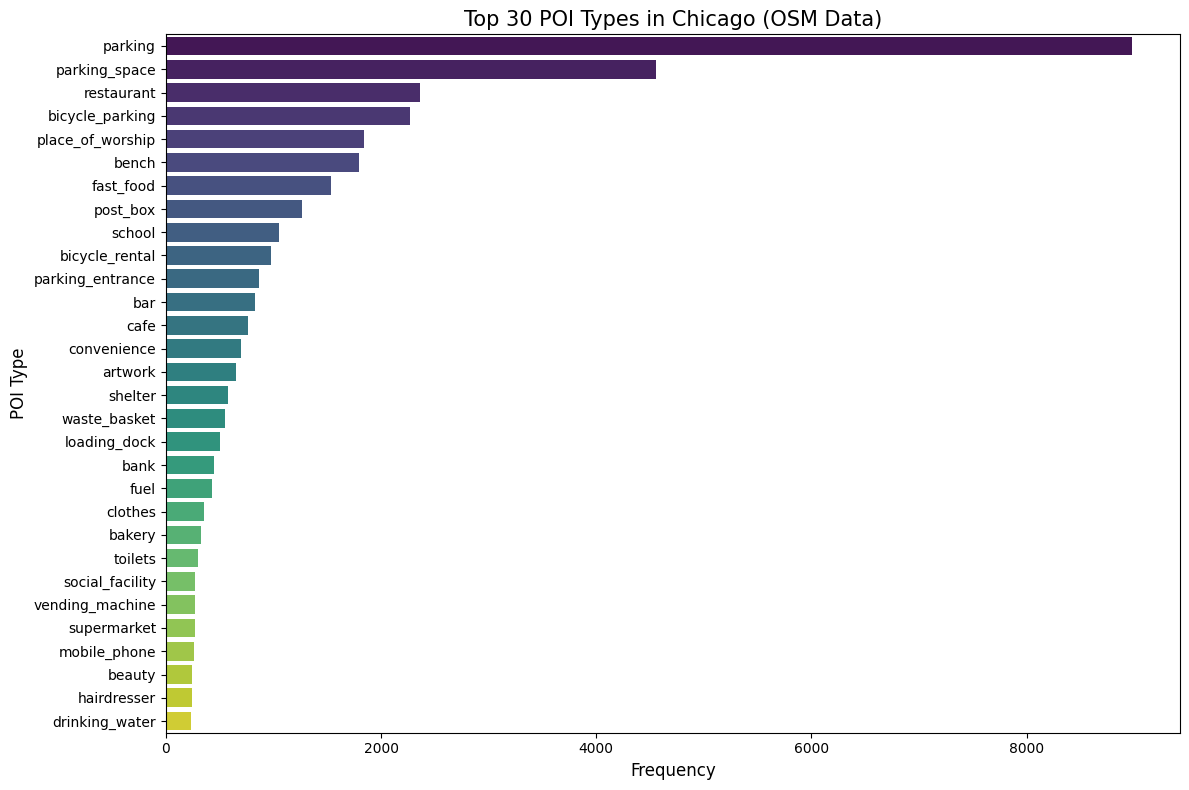

In [29]:
poi_counts = pois['poi_type'].value_counts().head(30) # Top 30 for clarity
# Create Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=poi_counts.values, y=poi_counts.index, palette='viridis', hue = poi_counts.index, legend=False)
plt.title('Top 30 POI Types in Chicago (OSM Data)', fontsize=15)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('POI Type', fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
unique_poi_types = pois['poi_type'].unique()

print(f"Total unique poi types: {len(unique_poi_types)}")
print(unique_poi_types)

Total unique poi types: 311
<StringArray>
[  'ferry_terminal', 'parking_entrance',         'post_box',
          'bicycle',     'loading_dock',          'theatre',
      'convenience',  'bicycle_parking',        'fast_food',
            'books',
 ...
       'fraternity',             'boat',       'theme_park',
     'boat_storage',    'street_vendor',      'trolley_bay',
   'security_booth',  'animal_training',  'outdoor_seating',
       'vacant;yes']
Length: 311, dtype: str


## Drop unneeded POIS
We decided to only use high-impact POIS and drop amenities that are infrastructure-related (unlikely to be a destination), hyper-local objects (clocks, benches), or private residential/specific use cases that don't generate high-frequency ride-hailing traffic.

In [31]:
values_to_drop = [
    'post_box', 'drinking_water', 'toilets', 'clock', 'fountain', 'bench', 
    'waste_basket', 'recycling', 'ticket_validator', 'shower', 'vending_machine', 
    'locker', 'bicycle_repair_station', 'public_bookcase', 'library_dropoff', 
    'waste_disposal', 'bbq', 'payment_terminal', 'photo_booth', 'grit_bin', 
    'letter_box', 'binoculars', 'waste_transfer_station', 'compressed_air', 
    'vacuum_cleaner', 'lounger', 'weighbridge', 'give_box', 'watering_place', 
    'Concrete Paving', 'bird_bath', 'dog_toilet', 'smoking_area', 'hitching_post', 
    'printer', 'trolley_bay', 'security_booth', 'stage', 'device_charging_station', 
    'parcel_locker', 'power_tools', 'window_blind', 'printer_ink', 'outpost', 
    'groundskeeping','parking', 'bicycle_parking', 'motorcycle_parking', 'bicycle_wash', 
    'loading_dock', 'parking_entrance', 'parking_exit', 'parking_space', 
    'bicycle', 'trail_riding_station', 'grave_yard', 'dojo', 'prep_school', 
    'public_bath', 'language_school', 'animal_shelter', 'animal_boarding', 
    'animal_breeding', 'animal_training', 'tool_library', 'lost_property_office', 
    'dressing_room', 'mortuary', 'monastery', 'car_pound', 'boat_storage', 
    'retirement_home', 'nursing_home', 'crematorium', 'prison', 'fraternity', 
    'camp_pitch', 'vacant', 'vacant;yes', 'yes', 'military_surplus'
]

# Reset index to turn 'osmid' into a column
pois = pois.reset_index()

# Rename 'osmid' to 'id' so your existing code works
pois = pois.rename(columns={'osmid': 'id'})

# Now your original filtering and selection will work
pois_cleaned = pois[~pois['poi_type'].isin(values_to_drop)]
pois = pois_cleaned[['id', 'poi_type', 'name', 'geometry']].dropna(subset=["geometry"])

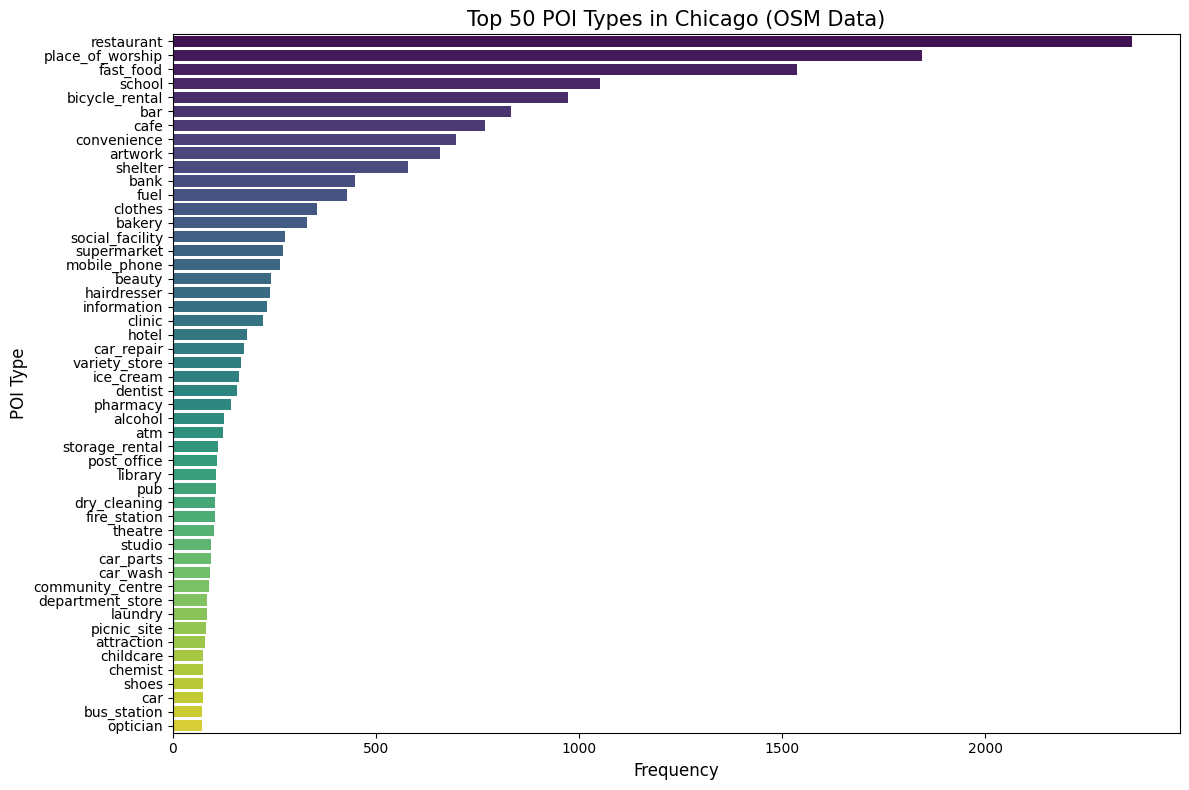

In [32]:
poi_counts = pois['poi_type'].value_counts().head(50) # Top 50 for clarity
# Create Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=poi_counts.values, y=poi_counts.index, palette='viridis', hue = poi_counts.index, legend=False)
plt.title('Top 50 POI Types in Chicago (OSM Data)', fontsize=15)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('POI Type', fontsize=12)
plt.tight_layout()
plt.show()